# SOB4ES - Modelo Random Forest
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo Random Forest.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. Configuracion: importaciones y parametros globales.
2. Carga de datos: se cargan los tres splits pre-generados.
3. Tuning: busqueda aleatoria de hiperparametros.
4. Validacion cruzada: evaluacion de robustez.
5. Explicabilidad (SHAP): analisis de importancia de variables.
6. Produccion: entrenamiento del ensamble final y exportacion.
7. Evaluacion final: rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno


In [9]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import shap
import matplotlib.pyplot as plt

# ignoramos los warnings
warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/RandomForest/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

TARGETS = [
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z'
]

FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'bac_total_reads_z',
    'fun_total_reads_z',
    'euk_total_reads_z',
    'oomy_total_reads_z',
    'cerc_total_reads_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

print('Librerias y variables cargadas...')


Librerias y variables cargadas...


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7 para garantizar una estimacion imparcial del rendimiento.

In [10]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 39)  |  X_test: (64, 39)  |  X_eval: (65, 39)


## 3.- Busqueda de hiperparametros (Tuning)

Se realiza una busqueda aleatoria (`RandomizedSearchCV`) sobre el espacio de hiperparametros de `RandomForestRegressor`. La busqueda se ejecuta exclusivamente sobre `X_train`. Como variable objetivo de referencia se usa `earthworm_shannon_z`.

Principales hiperparametros explorados:
- `n_estimators`: numero de arboles en el bosque.
- `max_depth`: profundidad maxima de cada arbol.
- `min_samples_split` / `min_samples_leaf`: criterios de parada para la division de nodos.
- `max_features`: numero de variables consideradas en cada split.
- `bootstrap`: si se usa muestreo con reemplazamiento.

In [11]:
print('Iniciando busqueda de hiperparametros (Tuning)...')
print('Este proceso puede tardar varios minutos.\n')

param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True, False]
}

y_prueba = y_train['earthworm_shannon_z'].values

buscador = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

start_tune = time.time()
buscador.fit(X_train, y_prueba)

print(f'\nBusqueda completada en {(time.time() - start_tune)/60:.1f} minutos.')
print(f'Mejor R2 obtenido: {buscador.best_score_:.4f}')
print(f'Hiperparametros optimos: {buscador.best_params_}')

RF_OPTIMAL_PARAMS = buscador.best_params_
RF_OPTIMAL_PARAMS['n_jobs'] = -1


Iniciando busqueda de hiperparametros (Tuning)...
Este proceso puede tardar varios minutos.

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/aka/Desktop/GitHub/TFG-SOB4ES/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aka/Desktop/GitHub/TFG-SOB4ES/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aka/Desktop/GitHub/TFG-SOB4ES/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aka/Deskto


Busqueda completada en 1.2 minutos.
Mejor R2 obtenido: 0.4958
Hiperparametros optimos: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None, 'bootstrap': True}


## 4.- Validacion cruzada

Se evalua la robustez del modelo mediante validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) sobre `X_train`. Comparando el rendimiento en entrenamiento y en validacion se puede detectar sobreajuste, algo especialmente relevante en Random Forest dado que puede memorizar los datos de entrenamiento con facilidad.

In [12]:
print('Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n')

modelo_cv   = RandomForestRegressor(**RF_OPTIMAL_PARAMS)
cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

resultados = cross_validate(
    estimator=modelo_cv,
    X=X_train,
    y=y_train['earthworm_shannon_z'].values,
    cv=cv_splitter,
    scoring=metricas,
    return_train_score=True
)

r2_train = np.mean(resultados['train_r2'])
r2_cv    = np.mean(resultados['test_r2'])
r2_std   = np.std(resultados['test_r2'])
rmse_cv  = np.mean(-resultados['test_neg_root_mean_squared_error'])
mae_cv   = np.mean(-resultados['test_neg_mean_absolute_error'])

print('Resultados (promedio de 15 evaluaciones):')
print(f'  Train R2          : {r2_train:.4f}')
print(f'  Validacion R2 (CV): {r2_cv:.4f} +/- {r2_std:.4f}')
print(f'  RMSE              : {rmse_cv:.4f} puntos de Shannon H\'')
print(f'  MAE               : {mae_cv:.4f} puntos de Shannon H\'')

diferencia = r2_train - r2_cv
if diferencia > 0.15:
    print(f'\nAviso: diferencia train/validacion = {diferencia:.4f}. Posible sobreajuste.')
else:
    print(f'\nDiferencia train/validacion = {diferencia:.4f}. El modelo generaliza correctamente.')


Validacion cruzada repetida (15 evaluaciones sobre X_train)...

Resultados (promedio de 15 evaluaciones):
  Train R2          : 0.8296
  Validacion R2 (CV): 0.4692 +/- 0.0957
  RMSE              : 0.7033 puntos de Shannon H'
  MAE               : 0.5129 puntos de Shannon H'

Aviso: diferencia train/validacion = 0.3604. Posible sobreajuste.


## 5.- Explicabilidad del modelo (SHAP)

Se utiliza SHAP (`TreeExplainer`) para analizar la importancia de las variables predictoras. `TreeExplainer` es compatible con `RandomForestRegressor` y calcula los valores de Shapley de forma exacta.

Interpretacion del grafico:
- Las variables se ordenan de mayor a menor importancia global.
- El color indica el valor de la variable (rojo = valor alto, azul = valor bajo).
- La posicion horizontal indica el efecto sobre la prediccion.

Calculando valores SHAP sobre X_train...
Top 10 variables por importancia SHAP (earthworm_shannon_z):


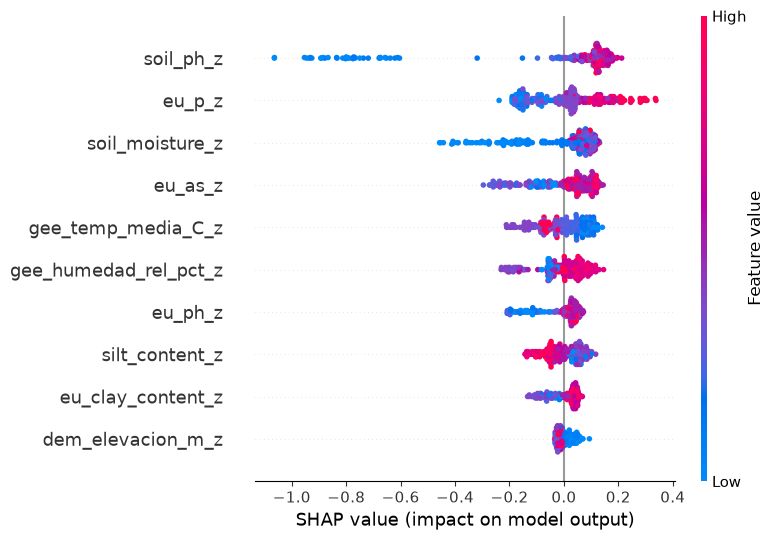

In [13]:
print('Calculando valores SHAP sobre X_train...')

modelo_shap = RandomForestRegressor(**RF_OPTIMAL_PARAMS)
modelo_shap.fit(X_train, y_train['earthworm_shannon_z'].values)

# TreeExplainer es compatible con RandomForest
explainer   = shap.TreeExplainer(modelo_shap)
shap_values = explainer.shap_values(X_train)

print('Top 10 variables por importancia SHAP (earthworm_shannon_z):')
shap.summary_plot(shap_values, X_train, plot_type='dot', max_display=10)


## 6.- Entrenamiento

Se entrena un ensamble de 5 modelos por cada variable objetivo, variando la semilla aleatoria. Esto complementa la aleatoridad intrinseca de Random Forest y reduce la varianza de las predicciones finales. Todos los modelos se guardan en disco en formato `.pkl`.

In [14]:
print('Entrenamiento de produccion (ensamble de 5 modelos por target)...')
print('-' * 70)

global_start = time.time()
NUM_MODELOS  = 5

for idx, target_col in enumerate(TARGETS, 1):
    t0 = time.time()
    y  = y_train[target_col].values

    for seed_id in range(NUM_MODELOS):
        params = RF_OPTIMAL_PARAMS.copy()
        params['random_state'] = 42 + seed_id

        model = RandomForestRegressor(**params)
        model.fit(X_train, y)

        joblib.dump(model, os.path.join(MODELS_DIR, f'rf_prod_{target_col}_m{seed_id}.pkl'))

    print(f'  [{idx}/{len(TARGETS)}] {target_col:30} completado ({time.time()-t0:.1f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time() - global_start)/60:.1f} minutos.')
print(f'Modelos guardados: {len(TARGETS) * NUM_MODELOS} ({NUM_MODELOS} por target).')


Entrenamiento de produccion (ensamble de 5 modelos por target)...
----------------------------------------------------------------------
  [1/11] nematode_shannon_z             completado (1.4s)
  [2/11] macro_shannon_z                completado (1.4s)
  [3/11] earthworm_shannon_z            completado (1.5s)
  [4/11] orib_shannon_z                 completado (1.4s)
  [5/11] meso_shannon_z                 completado (1.5s)
  [6/11] coll_shannon_z                 completado (1.4s)
  [7/11] bac_shannon_z                  completado (1.5s)
  [8/11] fun_shannon_z                  completado (1.4s)
  [9/11] euk_shannon_z                  completado (1.5s)
  [10/11] oomy_shannon_z                 completado (1.4s)
  [11/11] cerc_shannon_z                 completado (1.5s)
----------------------------------------------------------------------
Produccion completada en 0.3 minutos.
Modelos guardados: 55 (5 por target).


## 7.- Evaluacion final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimacion real del rendimiento en produccion. A continuacion se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Interpretacion del indice Shannon H':** 
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

In [15]:
test_target = 'earthworm_shannon_z'

# Evaluacion final sobre eval.csv
print('Evaluacion final sobre eval.csv')
print('-' * 50)

preds_eval = []
for seed_id in range(NUM_MODELOS):
    ruta  = os.path.join(MODELS_DIR, f'rf_prod_{test_target}_m{seed_id}.pkl')
    model = joblib.load(ruta)
    preds_eval.append(model.predict(X_eval))

y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval[test_target].values

print(f'  R2   : {r2_score(y_true_eval, y_pred_eval):.4f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_true_eval, y_pred_eval)):.4f} puntos de Shannon H\'')
print(f'  MAE  : {mean_absolute_error(y_true_eval, y_pred_eval):.4f} puntos de Shannon H\'')

# Smoke test
print("\nSmoke test - Inferencia con datos reales")
print("-" * 65)

try:
    # 1. Tomamos 3 filas reales al azar del dataset de evaluación
    df_new_data = X_eval.sample(n=3, random_state=42)
    
    # Extraemos también los índices originales y los valores reales
    indices_elegidos = df_new_data.index
    valores_reales = y_eval.loc[indices_elegidos, test_target].values
    
    votos = []

    # 2. Hacemos la predicción sobre las filas reales 
    for seed_id in range(NUM_MODELOS):
        ruta = os.path.join(MODELS_DIR, f"rf_prod_{test_target}_m{seed_id}.pkl")
        m    = joblib.load(ruta)
        pred = m.predict(df_new_data)
        votos.append(pred)

    # Calculamos la predicción final (promedio de los árboles de Random Forest)
    consenso = np.mean(votos, axis=0)
    
    # 3. Imprimimos los resultados desglosados muestra por muestra
    print("Resultados detallados por muestra evaluada:")
    print("-" * 65)
    
    for i, idx_muestra in enumerate(indices_elegidos):
        pred_val = consenso[i]
        real_val = valores_reales[i]
        error    = abs(pred_val - real_val)
        
        print(f"  Fila {idx_muestra:<4} | Predicción: {pred_val:.4f} | "
              f"Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}")

    print("-" * 65)
    print("\nSmoke test superado. El pipeline de Random Forest funciona y predice con coherencia.")

except Exception as e:
    print(f"Error en el smoke test: {str(e)}")


Evaluacion final sobre eval.csv
--------------------------------------------------
  R2   : 0.5359
  RMSE : 0.6800 puntos de Shannon H'
  MAE  : 0.4714 puntos de Shannon H'

Smoke test - Inferencia con datos reales
-----------------------------------------------------------------
Resultados detallados por muestra evaluada:
-----------------------------------------------------------------
  Fila 53   | Predicción: 0.6073 | Valor Real: 1.1347 | Error absoluto: 0.5274
  Fila 60   | Predicción: 0.9248 | Valor Real: 1.1388 | Error absoluto: 0.2140
  Fila 0    | Predicción: -0.4457 | Valor Real: -0.7453 | Error absoluto: 0.2995
-----------------------------------------------------------------

Smoke test superado. El pipeline de Random Forest funciona y predice con coherencia.
